## Canadian Golf Performance Analytics (CGPA)

### Overview
**Problem:** By looking at a golfer's past performance statistics, will the athlete be within the top 10 of the PGA Tour tournament?

This problem is a supervised prediction task. The data is based off of past PGA golf athlete performance statistics and the goal is to predict the future if each golfer would make it in the top 10 of the PGA Tour tournament.

### Data Loading & Documentation

In [22]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, root_mean_squared_error, r2_score
from matplotlib.colors import LinearSegmentedColormap

In [23]:
# Load CSV
df = pd.read_csv('ASA All PGA Raw Data - Tourn Level.csv')

# Display Info
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 36864 entries, 0 to 36863
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Player_initial_last  36864 non-null  str    
 1   tournament id        36864 non-null  int64  
 2   player id            36864 non-null  int64  
 3   hole_par             36864 non-null  int64  
 4   strokes              36864 non-null  int64  
 5   hole_DKP             36864 non-null  float64
 6   hole_FDP             36864 non-null  float64
 7   hole_SDP             36864 non-null  int64  
 8   streak_DKP           36864 non-null  int64  
 9   streak_FDP           36864 non-null  float64
 10  streak_SDP           36864 non-null  int64  
 11  n_rounds             36864 non-null  int64  
 12  made_cut             36864 non-null  int64  
 13  pos                  21317 non-null  float64
 14  finish_DKP           36864 non-null  int64  
 15  finish_FDP           36864 non-null  int64  
 1

,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,...,purse,season,no_cut,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total
0,A. Ancer,401353224,9261,288,289,60.0,51.1,56,3,7.6,...,12.0,2022,0,T32,0.20,-0.13,-0.08,0.86,0.65,0.85
1,A. Hadwin,401353224,5548,288,286,72.5,61.5,61,8,13.0,...,12.0,2022,0,T18,0.36,0.75,0.31,0.18,1.24,1.60
2,A. Lahiri,401353224,4989,144,147,21.5,17.4,27,0,0.0,...,12.0,2022,0,CUT,-0.56,0.74,-1.09,0.37,0.02,-0.54
3,A. Long,401353224,6015,144,151,20.5,13.6,17,0,0.4,...,12.0,2022,0,CUT,-1.46,-1.86,-0.02,0.80,-1.08,-2.54
4,A. Noren,401353224,3832,144,148,23.5,18.1,23,0,1.2,...,12.0,2022,0,CUT,0.53,-0.36,-1.39,0.19,-1.56,-1.04


#### Column Dictionary

| Column Name | Description |
| --- | --- |
| Player_initial_last | player name short |
| tournament id | tourney id |
| player id | unique player id |
| hole_par | number of pars across all rounds |
| strokes | player strokes total across all rounds |
| hole_DKP | DraftKings Points hole |
| hole_FDP | FanDuel Points hole |
| hole_SDP | SportsDataIO Points hole |
| streak_DKP | streak DraftKings Points |
| streak_FDP | streak FanDuel Points |
| streak_SDP | streak SportsDataIO Points |
| n_rounds | number of rounds |
| made_cut | made the cut |
| pos | position |
| finish_DKP | finish DraftKings Points |
| finish_FDP | finish FanDuel Points |
| finish_SDP | finish SportsDataIO Points |
| total_DKP | total DraftKings Points |
| total_FDP | total FanDuel Points |
| total_SDP | total SportsDataIO Points |
| player | player name |
| Unnamed: 2 | other 1 |
| Unnamed: 3 | other 2 |
| Unnamed: 4 | other 3 |
| tournament name | tournament |
| course | course |
| date | date |
| purse | purse amount in millions |
| season | season |
| no_cut | no cut |
| Finish | finish place |
| sg_putt | sg putting |
| sg_arg | strokes gained around the green |
| sg_app | strokes gained on approach shots |
| sg_ott | strokes gained off the tee |
| sg_t2g | strokes gained from tee to green |
| sg_total | strokes gained total |

#### Known Data Quality Issues

- `Unnamed: 2/3/4` have no data at all.
- `pos` (the finish position) is blank a lot of rows, mainly for players who missed the cut, withdrew, or tied. The `Finish` column instead is more complete, but it has issues (mentioned below).
- `sg_*` columns are blank for about some of rows and much more often in earlier seasons.
- `Finish` column mixes plain numbers (`"1"`), ties (`"T32"`), and status codes like `CUT`, `WD` and `W/D` (two different spellings for the same thing), `MDF`, and `DQ`.
- A few rows show the same player in the same tournament twice, and some of those duplicates even disagree on the result (one says "cut," the other says a finish position).
- Most tournaments have lots of players, but one row claims a tournament had only 1 player.
- `strokes` and `hole_par` are totals across all rounds played, not per round. They aren't directly comparable between players who played different numbers of rounds.

### Exploratory Data Analysis (EDA)

#### Feature Distributions

In [24]:
# Feature Engineering. The following will be done:
# 1. Derive the prediction whether a player will be in the top 10 (1) or not (0).
# 2. Combine two columns that describe how a player finishes:
#    - column pos is a numeric player finish position
#    - column Finish is a text description of the player's finish placement

# Parse the date column into an actual datetime so it can be used for chronological sorting later.
df['date'] = pd.to_datetime(df['date'])

# Status codes in Finish mean the player did not record a competitive position.
non_finish_codes = {'CUT', 'WD', 'W/D', 'MDF', 'DQ'}

def parse_finish(value):
    """Turn a Finish string like 'T32' or '5' into a numeric position, or NaN for status codes."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text in non_finish_codes:
        return np.nan
    text = text.lstrip('T')
    try:
        return float(text)
    except ValueError:
        return np.nan

df['finish_position_from_finish'] = df['Finish'].apply(parse_finish)

# Combine both sources, prefer the parsed Finish value, and fill the remaining gaps with pos,
# since the two columns are missing for different rows.
df['finish_position'] = df['finish_position_from_finish'].fillna(df['pos'])

# Rows carrying a recognized non finishing status code did not place in the Top 10, even when
# they have no numeric position. Also, any row that missed the cut is not in the Top 10.
non_finish_mask = df['Finish'].isin(non_finish_codes)
resolved_not_top10 = (df['finish_position'] > 10) | non_finish_mask | (df['made_cut'] == 0)

df['top_10'] = np.where(
    df['finish_position'] <= 10, 1,
    np.where(resolved_not_top10, 0, np.nan)
)

print('Top 10 target value counts, including unresolved NaN rows:')
print(df['top_10'].value_counts(dropna=False))

Top 10 target value counts, including unresolved NaN rows:
top_10
0.0    32793
1.0     3740
NaN      331
Name: count, dtype: int64


In [25]:
# Look at tournament features per player, but only consider those that are from the past.
# This would have been the set of features available to the coach before the start of the
# tournament.

df = df.sort_values(['player id', 'date']).reset_index(drop=True)
by_player = df.groupby('player id')

sg_cols = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'sg_total']

# Recent form: average strokes gained across the player's last 5 prior tournaments.
for col in sg_cols:
    df[f'{col}_prior5_avg'] = by_player[col].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )

# Career to date form: expanding average across every tournament the player has played before
# the current one.
for col in sg_cols:
    df[f'{col}_career_avg'] = by_player[col].transform(
        lambda s: s.shift(1).expanding().mean()
    )

# Recent consistency: share of the last 5 prior tournaments in which the player made the cut.
df['made_cut_prior5_rate'] = by_player['made_cut'].transform(
    lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
)

# Recent Top 10 rate: share of the last 5 prior tournaments that were Top 10 finishes.
df['top10_prior5_rate'] = by_player['top_10'].transform(
    lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
)

# Number of prior tournaments the player has on record. Low values flag rookies or players
# with a short history, where the rolling averages above are based on very little data.
df['prior_tournament_count'] = by_player.cumcount()

df[['player', 'date', 'sg_total', 'sg_total_prior5_avg', 'top10_prior5_rate', 'prior_tournament_count']].head(10)

,player,date,sg_total,sg_total_prior5_avg,top10_prior5_rate,prior_tournament_count
0,Robert Allenby,2014-10-12,NaN,NaN,NaN,0
1,Robert Allenby,2014-10-19,-1.45,NaN,1.000000,1
2,Robert Allenby,2014-10-26,NaN,-1.450000,0.500000,2
3,Robert Allenby,2014-11-02,NaN,-1.450000,0.333333,3
4,Robert Allenby,2014-11-16,NaN,-1.450000,0.250000,4
5,Robert Allenby,2015-01-18,-2.08,-1.450000,0.200000,5
6,Robert Allenby,2015-02-01,-0.64,-1.765000,0.000000,6
7,Robert Allenby,2015-02-08,-1.34,-1.360000,0.000000,7
8,Robert Allenby,2015-02-22,NaN,-1.353333,0.000000,8
9,Robert Allenby,2015-03-02,0.08,-1.353333,0.000000,9


#### Missing Value Handling

In [26]:
# Drop the fully empty columns identified in Known Data Quality Issues as they carry no information.
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

# Investigate rows where the same player and tournament id appear more than once.
duplicate_mask = df.duplicated(subset=['player id', 'tournament id'], keep=False)
print(f'Player and tournament duplicate rows: {duplicate_mask.sum()}')
print(
    df.loc[duplicate_mask, ['player', 'tournament id', 'made_cut', 'pos', 'Finish', 'sg_total']]
    .sort_values(['player', 'tournament id'])
)

# These duplicate pairs disagree with each other. For example one copy says CUT while the other
# gives a numeric finish, and in at least one case the two copies give different strokes gained
# values entirely. There is no reliable way to tell which copy is correct, so both copies of
# every duplicated player and tournament pair are dropped rather than guessing.
df = df.loc[~duplicate_mask].reset_index(drop=True)
print(f'Rows remaining after dropping duplicate player and tournament pairs: {len(df)}')

Player and tournament duplicate rows: 42
                 player  tournament id  made_cut   pos Finish  sg_total
31391     Cameron Smith           2233         1   NaN    CUT     -9.94
31392     Cameron Smith           2233         1   NaN    CUT     -2.10
31394     Cameron Smith           2245         1  46.0    T46      0.52
31395     Cameron Smith           2245         1  46.0    CUT     -2.48
31387     Cameron Smith           2254         0   NaN    CUT     -0.99
31388     Cameron Smith           2254         0   NaN    T43      0.21
31414     Cameron Smith           2502         0   NaN    CUT     -5.40
31415     Cameron Smith           2502         0   NaN    CUT     -3.40
31421     Cameron Smith           2510         1  22.0    T22      1.49
31422     Cameron Smith           2510         1  22.0    CUT     -3.34
18890         Danny Lee           2245         1  34.0    CUT     -6.48
18891         Danny Lee           2245         1  34.0    T34      3.52
18912         Danny Lee

In [27]:
# Investigate the tournament that appears to have only one player recorded.
tournament_sizes = df.groupby('tournament id').size()
smallest_tournament_id = tournament_sizes.idxmin()
print(f'Smallest tournament id {smallest_tournament_id} has {tournament_sizes.min()} player row(s):')
print(
    df.loc[df['tournament id'] == smallest_tournament_id,
           ['player', 'tournament name', 'season', 'made_cut', 'pos', 'Finish']]
)

# A player with no competitors in a tournament will of course finish at the top. This is a data
# entry error as tournaments always have many players. Drop every row where the Top 10 target
# could not be resolved from either Finish or pos.
unresolved_target = df['top_10'].isna()
print(f'Rows with an unresolved Top 10 target: {unresolved_target.sum()}')
df = df.loc[~unresolved_target].reset_index(drop=True)
df['top_10'] = df['top_10'].astype(int)
print(f'Rows remaining after dropping unresolved targets: {len(df)}')

Smallest tournament id 2251 has 1 player row(s):
           player         tournament name  season  made_cut  pos Finish
10129  Eric Axley  Travelers Championship    2015         1  NaN    NaN
Rows with an unresolved Top 10 target: 331
Rows remaining after dropping unresolved targets: 36491


In [28]:
# Check strokes gained coverage by season. Strokes gained tracking was not adopted across the
# PGA Tour until partway through the period covered by this data.
sg_nulls_by_season = df.groupby('season')['sg_total'].apply(lambda s: s.isna().sum())
print('Missing sg_total rows by season:')
print(sg_nulls_by_season)

# The strokes gained columns are central predictive features for this problem, so rows missing
# them are dropped instead of being interpreted.  Interpreting or guessing a skill statistic is
# not allowed as only measured values are accepted.
missing_sg = df['sg_total'].isna()
print(f'Rows missing sg_total: {missing_sg.sum()} out of {len(df)}')
df = df.loc[~missing_sg].reset_index(drop=True)
print(f'Rows remaining after dropping missing strokes gained rows: {len(df)}')

Missing sg_total rows by season:
season
2015    1405
2016    1154
2017    1099
2018     944
2019     771
2020     583
2021     834
2022     562
Name: sg_total, dtype: int64
Rows missing sg_total: 7352 out of 36491
Rows remaining after dropping missing strokes gained rows: 29139


#### Key Relationships

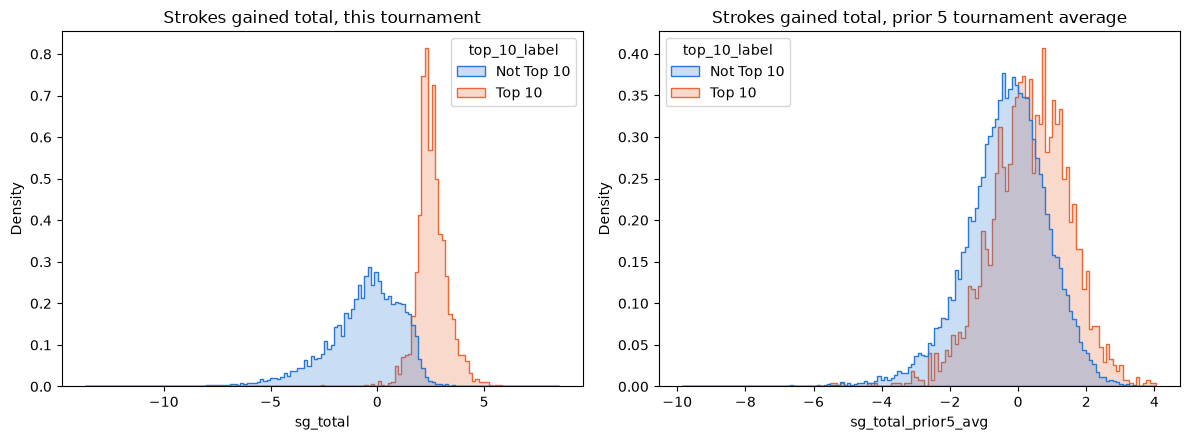

In [29]:
# Fixed categorical colors for the two groups being compared throughout this section.
color_not_top10 = '#2a78d6'  # categorical slot 1, blue
color_top10 = '#eb6834'      # categorical slot 2, orange

# A readable label column for legends, kept separate from the numeric top_10 target.
df['top_10_label'] = df['top_10'].map({0: 'Not Top 10', 1: 'Top 10'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col, title in zip(
    axes,
    ['sg_total', 'sg_total_prior5_avg'],
    ['Strokes gained total, this tournament', 'Strokes gained total, prior 5 tournament average']
):
    sns.histplot(
        data=df, x=col, hue='top_10_label', hue_order=['Not Top 10', 'Top 10'],
        palette={'Not Top 10': color_not_top10, 'Top 10': color_top10},
        stat='density', common_norm=False, element='step', ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

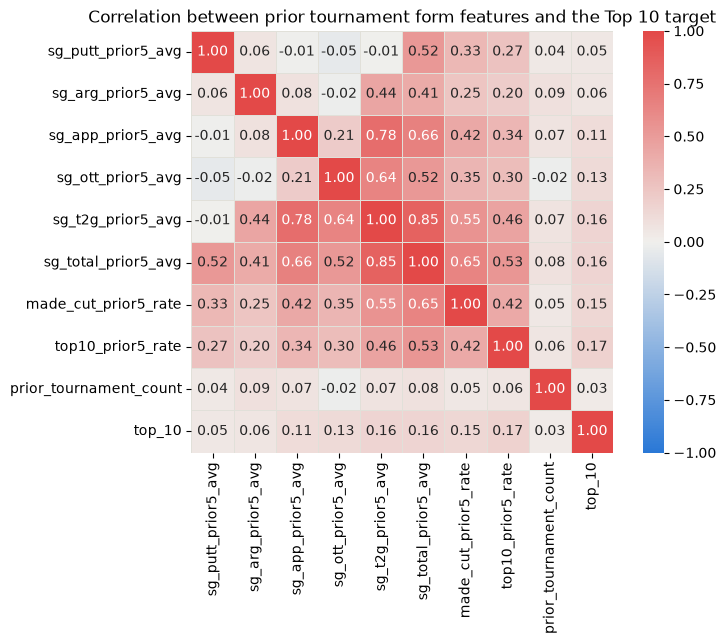

In [30]:
# Diverging pair from the design system: blue and red anchors around a neutral gray midpoint,
# used here because correlation runs from negative to positive around zero.
diverging_cmap = LinearSegmentedColormap.from_list(
    'blue_gray_red', ['#2a78d6', '#f0efec', '#e34948']
)

relationship_cols = [
    'sg_putt_prior5_avg', 'sg_arg_prior5_avg', 'sg_app_prior5_avg',
    'sg_ott_prior5_avg', 'sg_t2g_prior5_avg', 'sg_total_prior5_avg',
    'made_cut_prior5_rate', 'top10_prior5_rate', 'prior_tournament_count', 'top_10'
]

correlation = df[relationship_cols].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(
    correlation, cmap=diverging_cmap, center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', square=True, linewidths=0.5, linecolor='#e1e0d9'
)
plt.title('Correlation between prior tournament form features and the Top 10 target')
plt.tight_layout()
plt.show()

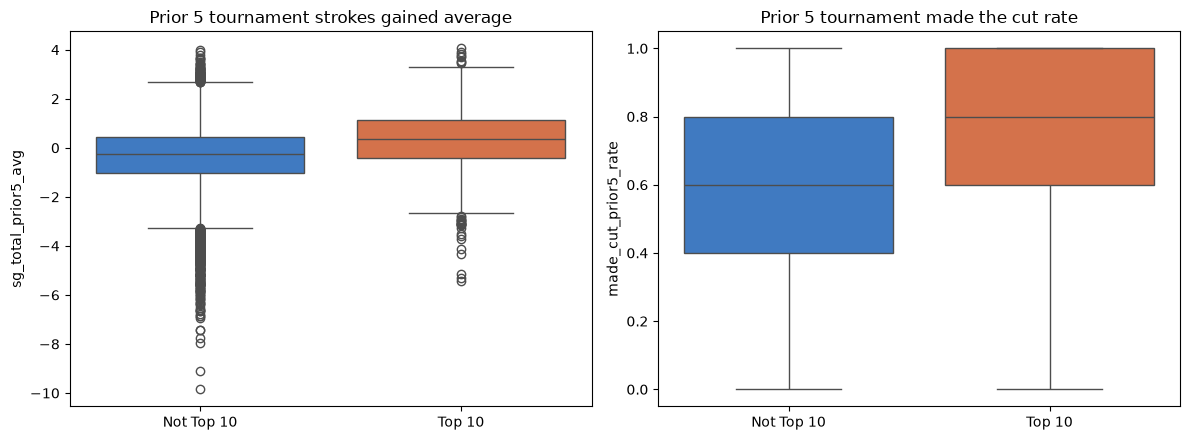

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col, title in zip(
    axes,
    ['sg_total_prior5_avg', 'made_cut_prior5_rate'],
    ['Prior 5 tournament strokes gained average', 'Prior 5 tournament made the cut rate']
):
    sns.boxplot(
        data=df, x='top_10_label', y=col, hue='top_10_label', legend=False,
        order=['Not Top 10', 'Top 10'],
        palette={'Not Top 10': color_not_top10, 'Top 10': color_top10},
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Problems Sections

### Assumptions Log

### Limitations

### Executive Summary

### Links